In [1]:
# Import Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_regression 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 

In [2]:
# Create Dataset 
# Create synthetic dataset 
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42) 
# Convert to DataFrame (CSV-like) 
df = pd.DataFrame({'Feature': X.flatten(), 'Target': y}) 
print(df.head()) 

    Feature     Target
0  0.931280  62.687202
1  0.087047 -23.763981
2 -1.057711 -25.686766
3  0.314247   7.936457
4 -0.479174 -15.475495


In [3]:
#Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [4]:
# UNDERFITTING MODEL (Too Simple) 
# Using Linear Regression (degree = 1) 
lin_model = LinearRegression() 
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# Predictions 
y_train_pred = lin_model.predict(X_train) 
y_test_pred = lin_model.predict(X_test) 

In [6]:
# Errors 
print("Underfitting Model:") 
print("Train MSE:", mean_squared_error(y_train, y_train_pred)) 
print("Test MSE:", mean_squared_error(y_test, y_test_pred)) 

Underfitting Model:
Train MSE: 291.6901115241318
Test MSE: 416.80890612748107


In [7]:
# OVERFITTING MODEL (Too Complex) 
# Using High-degree Polynomial (degree = 10) 
poly = PolynomialFeatures(degree=10) 
X_train_poly = poly.fit_transform(X_train) 
X_test_poly = poly.transform(X_test) 
poly_model = LinearRegression() 
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Predictions 
y_train_pred_poly = poly_model.predict(X_train_poly) 
y_test_pred_poly = poly_model.predict(X_test_poly) 
print("\nOverfitting Model:") 
print("Train MSE:", mean_squared_error(y_train, y_train_pred_poly)) 
print("Test MSE:", mean_squared_error(y_test, y_test_pred_poly))


Overfitting Model:
Train MSE: 284.91225243835265
Test MSE: 435.85200845328626


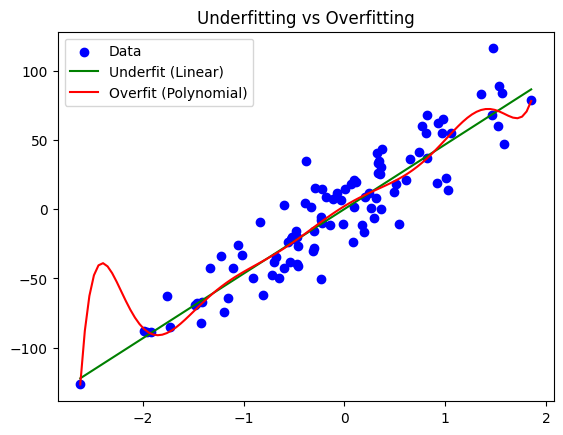

In [11]:
# Visualization 
# Sort for smooth curve 
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) 
# Linear prediction 
y_range_lin = lin_model.predict(X_range) 
# Polynomial prediction 
X_range_poly = poly.transform(X_range) 
y_range_poly = poly_model.predict(X_range_poly) 
plt.scatter(X, y, color='blue', label='Data') 
plt.plot(X_range, y_range_lin, color='green', label='Underfit (Linear)') 
plt.plot(X_range, y_range_poly, color='red', label='Overfit (Polynomial)') 
plt.legend() 
plt.title("Underfitting vs Overfitting") 
plt.show() 